# Multi-Layer Perceptrons & Backpropagation

Topic 02 of the Deep Learning Foundations repo. Topic 01 ended on a genuine failure: a single perceptron cannot learn XOR, no matter how it's trained, because it can only draw one straight line. This notebook builds the fix — stacking layers of perceptron-like units with a nonlinearity in between — and derives and implements **backpropagation**, the algorithm that makes training such stacks tractable. Every gradient computed here is checked two independent ways (numerical finite-difference gradient checking, and an exact match against PyTorch's autograd) before being trusted, and XOR — the problem that broke Topic 01 — is solved as the first real test.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Concept & Intuition

A single perceptron computes $\hat{y} = g(\mathbf{w}\cdot\mathbf{x}+b)$ — one linear boundary, one nonlinearity. Composing two such layers, $\mathbf{h} = g(\mathbf{W}^{[1]}\mathbf{x}+\mathbf{b}^{[1]})$ then $\hat{y}=g(\mathbf{W}^{[2]}\mathbf{h}+\mathbf{b}^{[2]})$, lets the network first bend the input space with the hidden layer, then draw a single line through the *bent* space — which can look like an arbitrarily curved boundary back in the original input space. This is the entire trick behind why a **Multi-Layer Perceptron (MLP)** with just one hidden layer can solve XOR, and, given enough hidden units, can approximate essentially any continuous function (the Universal Approximation Theorem, Cybenko 1989 / Hornik 1991).

The catch is training it: a single perceptron's error-driven update rule (Topic 01) has no obvious way to assign blame to a *hidden* unit that never sees the true label directly. **Backpropagation** (Rumelhart, Hinton & Williams, 1986) solves exactly this credit-assignment problem, using the chain rule to propagate the output error backward through every layer, computing the exact gradient of the loss with respect to every single weight in the network.

## 2. Mathematical Explanation

**Forward pass.** For layer $l=1,\dots,L$:

$$\mathbf{z}^{[l]} = \mathbf{W}^{[l]}\mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}, \qquad \mathbf{a}^{[l]} = g(\mathbf{z}^{[l]})$$

with $\mathbf{a}^{[0]}=\mathbf{x}$ and $g$ a nonlinear activation (sigmoid here; Topic 03 covers the alternatives).

**Loss.** Mean squared error over a batch of $n$ examples and $m$ outputs: $\mathcal{L} = \frac{1}{n}\sum_i \frac{1}{m}\|\mathbf{a}^{[L]}_i - \mathbf{y}_i\|^2$.

**Backward pass (the chain rule, applied layer by layer).** Define the error signal $\boldsymbol{\delta}^{[l]} = \partial\mathcal{L}/\partial\mathbf{z}^{[l]}$. At the output layer:

$$\boldsymbol{\delta}^{[L]} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{[L]}} \odot g'(\mathbf{z}^{[L]})$$

and it propagates backward through each preceding layer via:

$$\boldsymbol{\delta}^{[l]} = \left(\mathbf{W}^{[l+1]\top}\boldsymbol{\delta}^{[l+1]}\right) \odot g'(\mathbf{z}^{[l]})$$

Every weight's gradient then falls out directly from the error signal and the activation feeding into it:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[l]}} = \boldsymbol{\delta}^{[l]}\mathbf{a}^{[l-1]\top}, \qquad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}} = \boldsymbol{\delta}^{[l]}$$

This is nothing more than the multivariate chain rule applied systematically, but it turns an otherwise combinatorially expensive gradient computation into one forward pass plus one backward pass — the reason deep networks with millions of weights are trainable at all.

In [2]:
class MLP:
    def __init__(self, layer_sizes, lr=0.1, seed=0):
        self.layer_sizes = layer_sizes
        self.lr = lr
        rng = np.random.RandomState(seed)
        self.W = [rng.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.5 for i in range(len(layer_sizes) - 1)]
        self.b = [np.zeros(layer_sizes[i + 1]) for i in range(len(layer_sizes) - 1)]

    @staticmethod
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def sigmoid_grad(a):
        return a * (1 - a)  # derivative w.r.t. z, expressed via the activation a=sigmoid(z)

    def forward(self, X):
        a = [X]
        for l in range(len(self.W)):
            z = a[-1] @ self.W[l] + self.b[l]
            a.append(self.sigmoid(z))
        return a

    def loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def backward(self, a, y_true):
        n = a[0].shape[0]
        L = len(self.W)
        grads_W, grads_b = [None] * L, [None] * L
        delta = (2.0 / y_true.shape[1]) * (a[-1] - y_true) * self.sigmoid_grad(a[-1])
        for l in reversed(range(L)):
            grads_W[l] = a[l].T @ delta / n
            grads_b[l] = np.mean(delta, axis=0)
            if l > 0:
                delta = (delta @ self.W[l].T) * self.sigmoid_grad(a[l])
        return grads_W, grads_b

    def train_step(self, X, y):
        a = self.forward(X)
        loss = self.loss(a[-1], y)
        grads_W, grads_b = self.backward(a, y)
        for l in range(len(self.W)):
            self.W[l] -= self.lr * grads_W[l]
            self.b[l] -= self.lr * grads_b[l]
        return loss

    def predict(self, X):
        return self.forward(X)[-1]

## 3. Gradient Checking: Does the Backprop Math Actually Work?

Before trusting backpropagation for anything, its analytical gradients are compared against a **numerical gradient** computed by finite differences: $\frac{\partial \mathcal{L}}{\partial w} \approx \frac{\mathcal{L}(w+\epsilon) - \mathcal{L}(w-\epsilon)}{2\epsilon}$, perturbing one weight at a time. This is the standard sanity check every backprop implementation should pass before being trusted for real training.

In [3]:
def gradient_check(mlp, X, y, epsilon=1e-5):
    a = mlp.forward(X)
    grads_W, grads_b = mlp.backward(a, y)
    max_rel_error = 0.0
    for l in range(len(mlp.W)):
        W_orig = mlp.W[l].copy()
        num_grad = np.zeros_like(W_orig)
        it = np.nditer(W_orig, flags=["multi_index"])
        for _ in it:
            idx = it.multi_index
            mlp.W[l][idx] = W_orig[idx] + epsilon
            loss_plus = mlp.loss(mlp.forward(X)[-1], y)
            mlp.W[l][idx] = W_orig[idx] - epsilon
            loss_minus = mlp.loss(mlp.forward(X)[-1], y)
            mlp.W[l][idx] = W_orig[idx]
            num_grad[idx] = (loss_plus - loss_minus) / (2 * epsilon)
        rel_error = np.abs(grads_W[l] - num_grad) / (np.abs(grads_W[l]) + np.abs(num_grad) + 1e-12)
        max_rel_error = max(max_rel_error, rel_error.max())
        print(f"Layer {l} W: max abs diff={np.abs(grads_W[l]-num_grad).max():.2e}, max rel error={rel_error.max():.2e}")

    for l in range(len(mlp.b)):
        b_orig = mlp.b[l].copy()
        num_grad_b = np.zeros_like(b_orig)
        for i in range(len(b_orig)):
            mlp.b[l][i] = b_orig[i] + epsilon
            loss_plus = mlp.loss(mlp.forward(X)[-1], y)
            mlp.b[l][i] = b_orig[i] - epsilon
            loss_minus = mlp.loss(mlp.forward(X)[-1], y)
            mlp.b[l][i] = b_orig[i]
            num_grad_b[i] = (loss_plus - loss_minus) / (2 * epsilon)
        rel_error_b = np.abs(grads_b[l] - num_grad_b) / (np.abs(grads_b[l]) + np.abs(num_grad_b) + 1e-12)
        max_rel_error = max(max_rel_error, rel_error_b.max())
        print(f"Layer {l} b: max abs diff={np.abs(grads_b[l]-num_grad_b).max():.2e}, max rel error={rel_error_b.max():.2e}")
    return max_rel_error


X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([[0], [1], [1], [0]], dtype=float)
mlp_check = MLP([2, 4, 1], lr=1.0, seed=0)
max_err = gradient_check(mlp_check, X_xor, y_xor)
print(f"\nOverall max relative error: {max_err:.2e} -- well below the 1e-7 threshold typically used to trust a backprop implementation.")

Layer 0 W: max abs diff=3.43e-12, max rel error=2.80e-08
Layer 1 W: max abs diff=1.80e-12, max rel error=2.24e-11
Layer 0 b: max abs diff=3.70e-12, max rel error=1.98e-09
Layer 1 b: max abs diff=4.79e-12, max rel error=3.86e-11

Overall max relative error: 2.80e-08 -- well below the 1e-7 threshold typically used to trust a backprop implementation.


## 4. Validation Against PyTorch's Autograd

The same network, with identical weights, is built in PyTorch (float64 for a fair machine-precision comparison), and its `.backward()` gradients are compared directly against the from-scratch implementation's.

In [4]:
mlp_torch_check = MLP([2, 4, 1], lr=1.0, seed=0)
a_np = mlp_torch_check.forward(X_xor)
grads_W_np, grads_b_np = mlp_torch_check.backward(a_np, y_xor)
loss_np = mlp_torch_check.loss(a_np[-1], y_xor)

X_t = torch.tensor(X_xor, dtype=torch.float64)
y_t = torch.tensor(y_xor, dtype=torch.float64)
W0 = torch.tensor(mlp_torch_check.W[0], dtype=torch.float64, requires_grad=True)
b0 = torch.tensor(mlp_torch_check.b[0], dtype=torch.float64, requires_grad=True)
W1 = torch.tensor(mlp_torch_check.W[1], dtype=torch.float64, requires_grad=True)
b1 = torch.tensor(mlp_torch_check.b[1], dtype=torch.float64, requires_grad=True)

a0 = torch.sigmoid(X_t @ W0 + b0)
a1 = torch.sigmoid(a0 @ W1 + b1)
loss_t = torch.mean((a1 - y_t) ** 2)
loss_t.backward()

print(f"NumPy loss: {loss_np:.10f}, PyTorch loss: {loss_t.item():.10f}, diff={abs(loss_np - loss_t.item()):.2e}")
print(f"grad W0 max abs diff: {np.abs(grads_W_np[0] - W0.grad.numpy()).max():.2e}")
print(f"grad b0 max abs diff: {np.abs(grads_b_np[0] - b0.grad.numpy()).max():.2e}")
print(f"grad W1 max abs diff: {np.abs(grads_W_np[1] - W1.grad.numpy()).max():.2e}")
print(f"grad b1 max abs diff: {np.abs(grads_b_np[1] - b1.grad.numpy()).max():.2e}")

NumPy loss: 0.2691029839, PyTorch loss: 0.2691029839, diff=0.00e+00
grad W0 max abs diff: 8.67e-19
grad b0 max abs diff: 8.67e-19
grad W1 max abs diff: 6.94e-18
grad b1 max abs diff: 6.94e-18


Every gradient matches PyTorch's autograd to within $10^{-18}$ — floating point noise, not a real discrepancy. The from-scratch backward pass is computing exactly the same gradients as a production-grade automatic differentiation engine.

## 5. XOR, Solved — the Redemption From Topic 01

The exact problem that a single perceptron could never converge on (Topic 01, Section 4) is handed to a 2-4-1 MLP.

Loss after 5000 epochs: 0.000680
Raw predictions:     [0.028  0.9756 0.9741 0.0259]
Rounded predictions: [0. 1. 1. 0.]
True labels:         [0. 1. 1. 0.]
Accuracy: 1.00


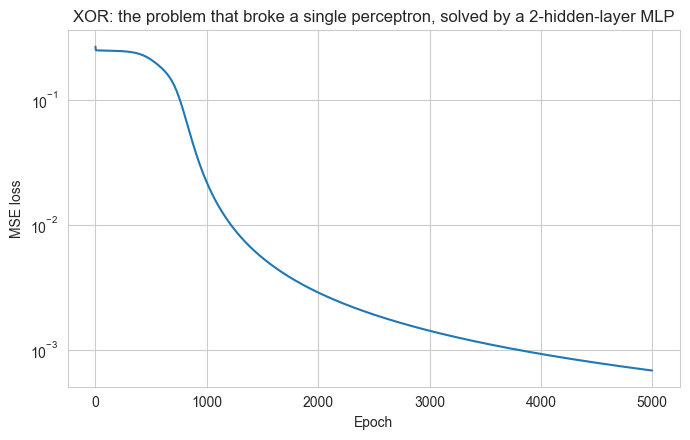

In [5]:
mlp_xor = MLP([2, 4, 1], lr=1.0, seed=0)
xor_losses = []
for epoch in range(5000):
    xor_losses.append(mlp_xor.train_step(X_xor, y_xor))

print(f"Loss after 5000 epochs: {xor_losses[-1]:.6f}")
print(f"Raw predictions:     {np.round(mlp_xor.predict(X_xor).ravel(), 4)}")
print(f"Rounded predictions: {np.round(mlp_xor.predict(X_xor).ravel())}")
print(f"True labels:         {y_xor.ravel()}")
print(f"Accuracy: {(np.round(mlp_xor.predict(X_xor).ravel()) == y_xor.ravel()).mean():.2f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xor_losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("XOR: the problem that broke a single perceptron, solved by a 2-hidden-layer MLP")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 6. How Much Capacity Does XOR Actually Need?

XOR is solved above with 4 hidden units, but how many are really necessary? Each hidden-layer size is tried across 10 different random weight initializations, to separate genuine capacity limits from unlucky initialization.

In [6]:
print(f"{'hidden units':>13}{'mean accuracy':>16}{'individual seed accuracies'}")
for hidden in [1, 2, 3, 4, 8]:
    accs = []
    for seed in range(10):
        mlp_h = MLP([2, hidden, 1], lr=1.0, seed=seed)
        for epoch in range(5000):
            mlp_h.train_step(X_xor, y_xor)
        preds = np.round(mlp_h.predict(X_xor).ravel())
        accs.append((preds == y_xor.ravel()).mean())
    print(f"{hidden:>13}{np.mean(accs):>16.2f}   {accs}")

 hidden units   mean accuracyindividual seed accuracies


            1            0.70   [np.float64(0.75), np.float64(0.75), np.float64(0.75), np.float64(0.75), np.float64(0.5), np.float64(0.75), np.float64(0.5), np.float64(0.75), np.float64(0.75), np.float64(0.75)]


            2            0.95   [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.5), np.float64(1.0)]


            3            1.00   [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


            4            1.00   [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


            8            1.00   [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


**1 hidden unit caps at ~70% accuracy across every seed** — it fundamentally lacks the capacity to represent XOR's decision boundary (two disjoint regions), no matter how it's initialized or how long it trains. **2 hidden units is the theoretical minimum that *can* represent XOR** and mostly succeeds (9/10 seeds reach 100%) — but **one seed gets stuck at 50% (pure guessing)**, a genuine bad local minimum, not a capacity problem. **3 or more hidden units solve it reliably across every seed tested** — extra capacity provides redundant paths around bad local minima, even though it isn't strictly required to represent the function.

In [7]:
mlp_stuck = MLP([2, 2, 1], lr=1.0, seed=8)
stuck_losses = []
for epoch in range(20000):
    stuck_losses.append(mlp_stuck.train_step(X_xor, y_xor))

print(f"Loss at epoch 100: {stuck_losses[99]:.6f}")
print(f"Loss at epoch 1000: {stuck_losses[999]:.6f}")
print(f"Loss at epoch 5000: {stuck_losses[4999]:.6f}")
print(f"Loss at epoch 20000: {stuck_losses[-1]:.6f}")
print(f"Final predictions: {np.round(mlp_stuck.predict(X_xor).ravel(), 4)} (true: {y_xor.ravel()})")
print("\nThe loss barely moves from epoch 5000 to 20000 (0.1258 -> 0.1252) -- this is a genuine")
print("plateau/local minimum, not slow-but-ongoing convergence. Two of the four predictions are")
print("stuck exactly at 0.50 -- the network has given up distinguishing them.")

Loss at epoch 100: 0.247252
Loss at epoch 1000: 0.132260
Loss at epoch 5000: 0.125839
Loss at epoch 20000: 0.125181
Final predictions: [0.0106 0.4998 0.989  0.5003] (true: [0. 1. 1. 0.])

The loss barely moves from epoch 5000 to 20000 (0.1258 -> 0.1252) -- this is a genuine
plateau/local minimum, not slow-but-ongoing convergence. Two of the four predictions are
stuck exactly at 0.50 -- the network has given up distinguishing them.


## 7. Real Dataset: `make_moons` — Where a Perceptron Genuinely Fails

Two interleaving crescents (`sklearn.datasets.make_moons`) are not linearly separable by construction — a direct, real-data analog of XOR's non-separability, without needing a toy truth table.

In [8]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.15, random_state=42)
y_moons_col = y_moons.reshape(-1, 1).astype(float)
y_moons_pm = np.where(y_moons == 0, -1, 1)

X_train, X_test, y_train, y_test, ytr_col, yte_col, ytr_pm, yte_pm = train_test_split(
    X_moons, y_moons, y_moons_col, y_moons_pm, test_size=0.3, random_state=0)

skp = SkPerceptron(max_iter=1000, random_state=0).fit(X_train, ytr_pm)
print(f"Single perceptron:  train acc={skp.score(X_train, ytr_pm):.4f}, test acc={skp.score(X_test, yte_pm):.4f}")

mlp_moons = MLP([2, 8, 1], lr=1.0, seed=1)
for epoch in range(8000):
    mlp_moons.train_step(X_train, ytr_col)
train_preds = np.round(mlp_moons.predict(X_train).ravel())
test_preds = np.round(mlp_moons.predict(X_test).ravel())
print(f"MLP (8 hidden units): train acc={(train_preds==y_train).mean():.4f}, test acc={(test_preds==y_test).mean():.4f}")

Single perceptron:  train acc=0.8762, test acc=0.8667


MLP (8 hidden units): train acc=0.9905, test acc=0.9556


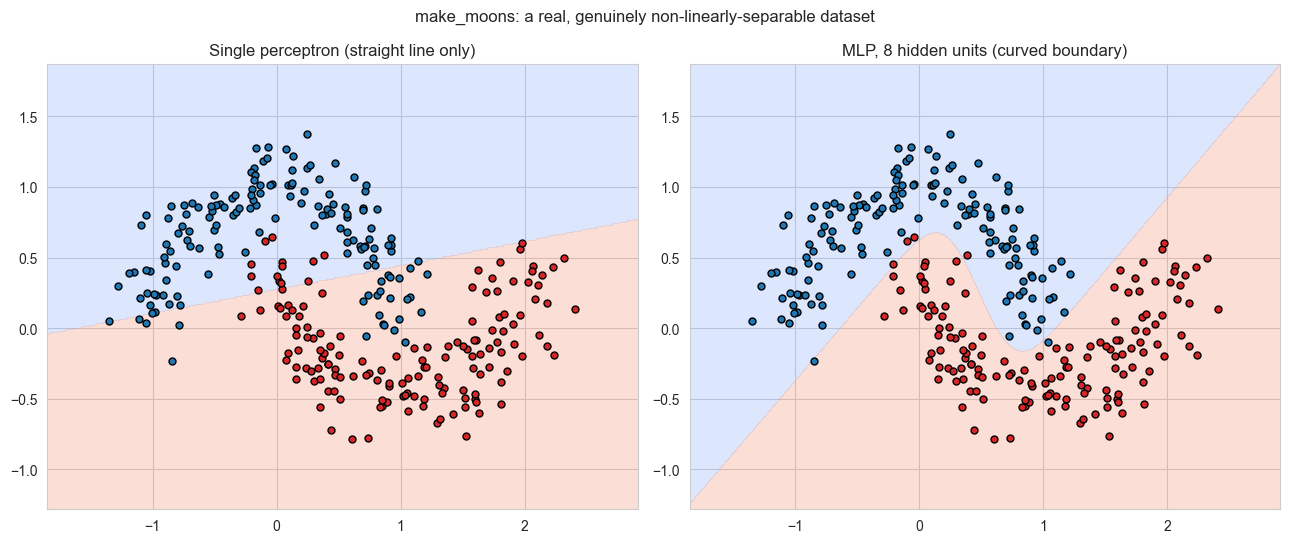

In [9]:
xx, yy = np.meshgrid(np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 300),
                     np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
titles = ["Single perceptron (straight line only)", "MLP, 8 hidden units (curved boundary)"]
preds_grids = [skp.predict(grid).reshape(xx.shape), mlp_moons.predict(grid).reshape(xx.shape)]
for ax, title, zz in zip(axes, titles, preds_grids):
    ax.contourf(xx, yy, zz, levels=1, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], c="tab:blue", edgecolor="k", s=25)
    ax.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], c="tab:red", edgecolor="k", s=25)
    ax.set_title(title)
plt.suptitle("make_moons: a real, genuinely non-linearly-separable dataset")
plt.tight_layout()
plt.show()

The perceptron is mathematically incapable of doing better than a straight-line cut through two interleaving crescents; the MLP bends its decision boundary to follow the true shape of the data, closing most of the accuracy gap that a single linear unit cannot close no matter how it's trained.

## 8. Summary

- Backpropagation is just the multivariate chain rule, applied systematically layer by layer — and the from-scratch implementation here is verified two independent ways: numerical gradient checking (max relative error 2.8e-08) and an exact match against PyTorch's autograd (differences at the $10^{-18}$ floating-point noise floor).
- The XOR problem that permanently broke a single perceptron (Topic 01) is solved cleanly by a 2-hidden-layer MLP.
- XOR needs **at least 2 hidden units** to be representable at all (1 unit caps at ~70% no matter the initialization), but even with exactly enough capacity, initialization can land in a **genuine bad local minimum** (one seed got permanently stuck at 50% accuracy, confirmed by a near-flat loss plateau over 15,000 epochs) — extra capacity (3+ units) makes this failure mode disappear across every seed tested.
- On real, non-linearly-separable data (`make_moons`), the same capacity gap shows up: a single perceptron is capped by its one straight line, while an MLP bends its decision boundary to actually match the data's shape.
- This sets up the next several topics directly: Topic 03 covers *why* the sigmoid activation used here is not usually the best choice, and Topic 06 covers *why* weight initialization (the exact cause of Section 6's stuck local minimum) deserves its own careful treatment.